<a href="https://colab.research.google.com/github/MalakMaher780/Projects-/blob/main/Analysis_of_time_series_data_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
#Load + Prepare Data
import pandas as pd
df = pd.read_csv("/content/1_Daily_minimum_temps.csv")
print(df.head())
print(df.columns)

       Date  Temp
0  01/01/81  20.7
1  01/02/81  17.9
2  01/03/81  18.8
3  01/04/81  14.6
4  01/05/81  15.8
Index(['Date', 'Temp'], dtype='object')


In [56]:
#Convert Date + Set Index
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

print(df.head())

/tmp/ipykernel_14602/3786862212.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


In [58]:
df["Temp"] = pd.to_numeric(df["Temp"], errors="coerce")

In [59]:
df = df.dropna()


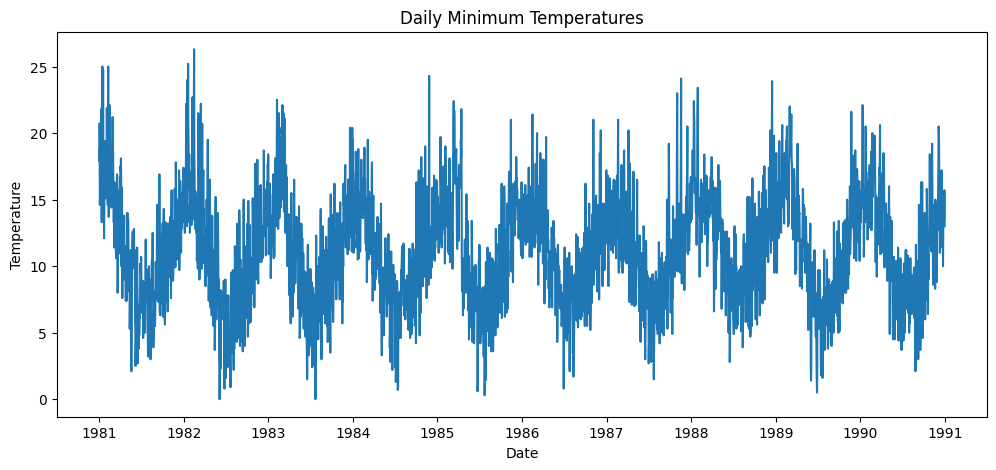

In [60]:
import matplotlib.pyplot as plt
#Plot Time Series
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Temp"])
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Daily Minimum Temperatures")
plt.show()

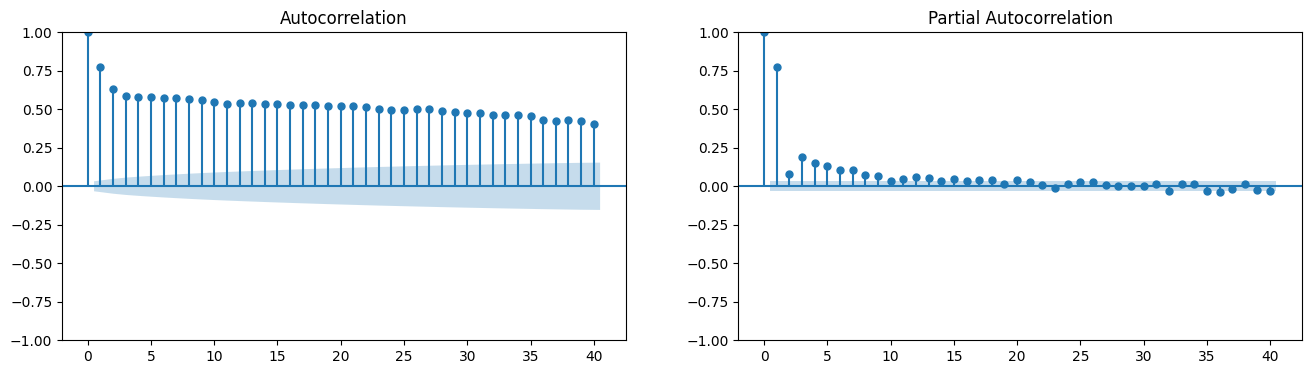

In [41]:
#4. ACF & PACF (Task 3)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Generate ACF/PACF for raw data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df["Temp"], lags=40, ax=ax1)
plot_pacf(df["Temp"], lags=40, ax=ax2)
plt.show()

In [62]:
#ADF Test (Stationarity Check)
#Before differencing
result = adfuller(df.iloc[:,0])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.444652847181708
p-value: 0.00024723724658534517


In [66]:
#6. First Differencing (Task 4)
df_diff = df.diff().dropna()

In [67]:
#After differencing
from statsmodels.tsa.stattools import adfuller

# Apply First Differencing
df_diff = df["Temp"].diff().dropna()

# ADF Test to confirm stationarity
result = adfuller(df_diff)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # If p < 0.05, it is stationary

ADF Statistic: -21.079000399668345
p-value: 0.0


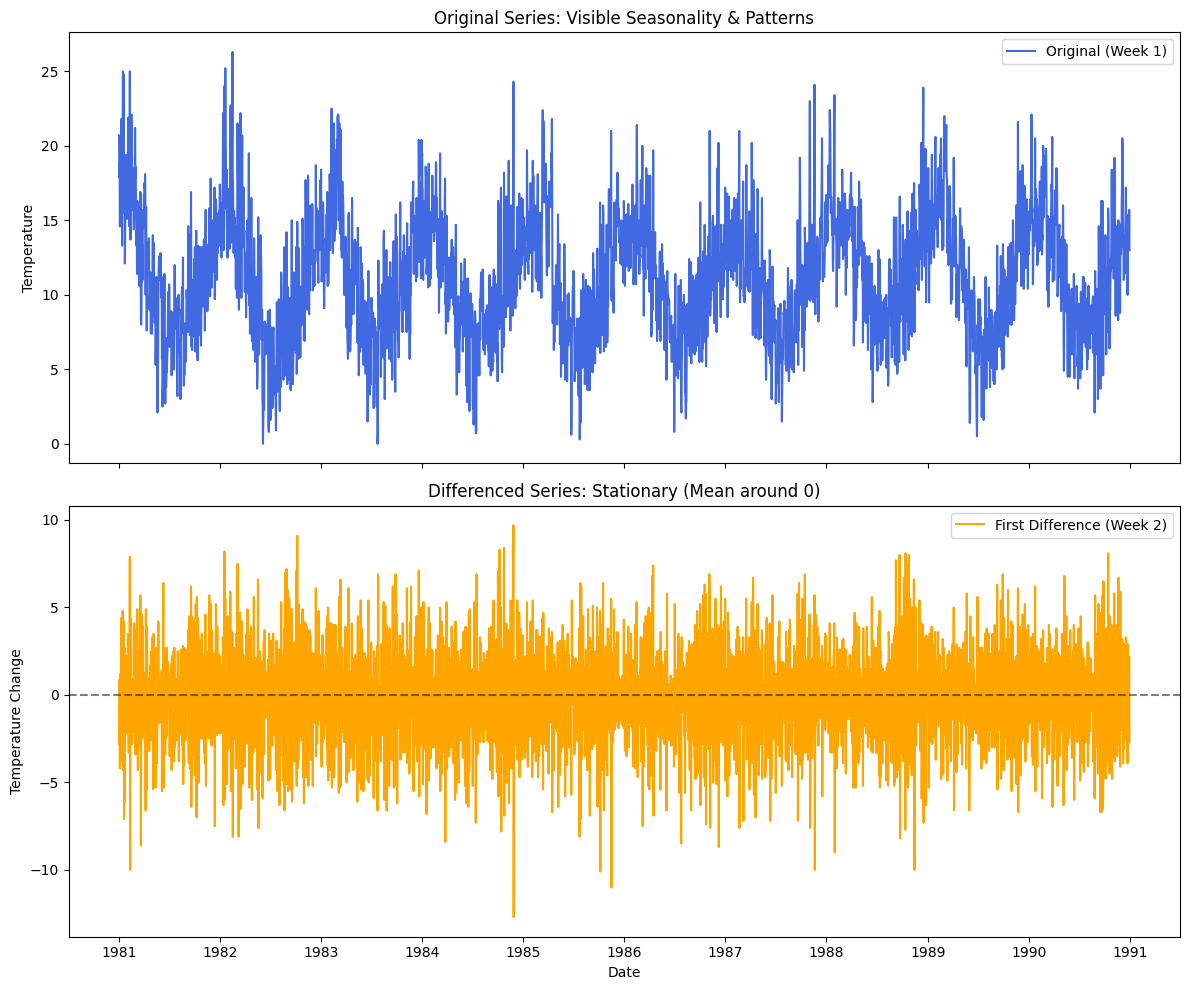

In [69]:
#Plot Differenced Series
import matplotlib.pyplot as plt

# 1. Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 2. Plot Original Data (Non-Stationary due to Seasonality)
ax1.plot(df.index, df["Temp"], color='royalblue', label='Original (Week 1)')
ax1.set_title("Original Series: Visible Seasonality & Patterns")
ax1.set_ylabel("Temperature")
ax1.legend()

# 3. Plot Differenced Data (Stationary)
# df_diff was calculated as: df["Temp"].diff().dropna()
ax2.plot(df_diff.index, df_diff, color='orange', label='First Difference (Week 2)')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5) # Add a line at zero
ax2.set_title("Differenced Series: Stationary (Mean around 0)")
ax2.set_ylabel("Temperature Change")
ax2.set_xlabel("Date")
ax2.legend()

plt.tight_layout()
plt.show()

<Figure size 1200x400 with 0 Axes>

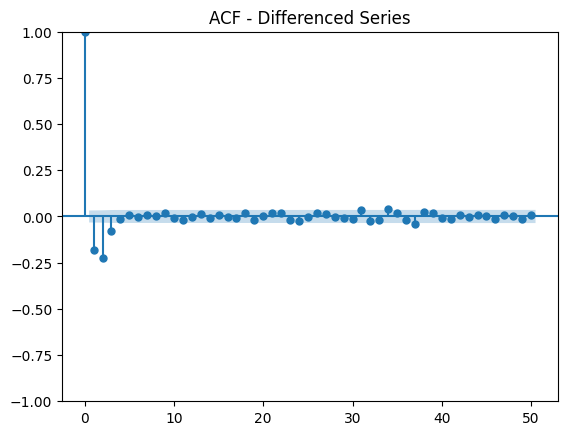

<Figure size 1200x400 with 0 Axes>

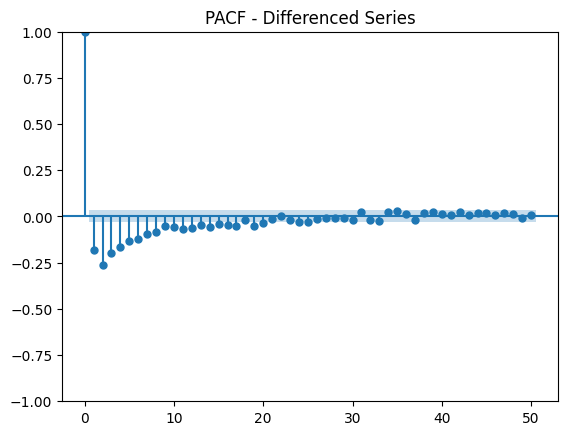

In [70]:
#ACF & PACF After Differencing
plt.figure(figsize=(12,4))
plot_acf(df_diff, lags=50)
plt.title("ACF - Differenced Series")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df_diff, lags=50)
plt.title("PACF - Differenced Series")
plt.show()

In [47]:
train_size = int(len(df) * 0.8)

train = df["Temp"][:train_size]
test = df["Temp"][train_size:]

print(len(train), len(test))

2917 730


In [75]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.6 MB/s eta 0:00:00


In [83]:
#Auto-ARIMA (Task 5)
import pmdarima as pm
ts = df['Temp']
model = pm.auto_arima(
    ts,
    seasonal=False,
    stepwise=True,
    trace=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=16776.362, Time=2.32 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=28416.219, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=17639.947, Time=0.13 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=24501.998, Time=0.18 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=16812.149, Time=0.64 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=16826.585, Time=1.07 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=16825.110, Time=1.83 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=16776.348, Time=1.52 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=16774.564, Time=0.36 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=21073.407, Time=1.10 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=16776.451, Time=0.71 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=22308.916, Time=0.33 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=20349.270, Time=0.73 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=16777.706, Time=1.84 sec
 ARIMA(1,0,3)(0,0,0

In [85]:
print("ARIMA order:", model.order)

ARIMA order: (1, 1, 2)


In [86]:
#Fit ARIMA
from statsmodels.tsa.arima.model import ARIMA

p, d, q = model.order

arima_model = ARIMA(ts, order=(p,d,q))
arima_result = arima_model.fit()

print(arima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3647
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -8379.383
Date:                Sat, 09 May 2026   AIC                          16766.765
Time:                        13:49:58   BIC                          16791.571
Sample:                             0   HQIC                         16775.600
                               - 3647                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2435      0.039      6.272      0.000       0.167       0.320
ma.L1         -0.6505      0.039    -16.674      0.000      -0.727      -0.574
ma.L2         -0.2335      0.031     -7.479      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


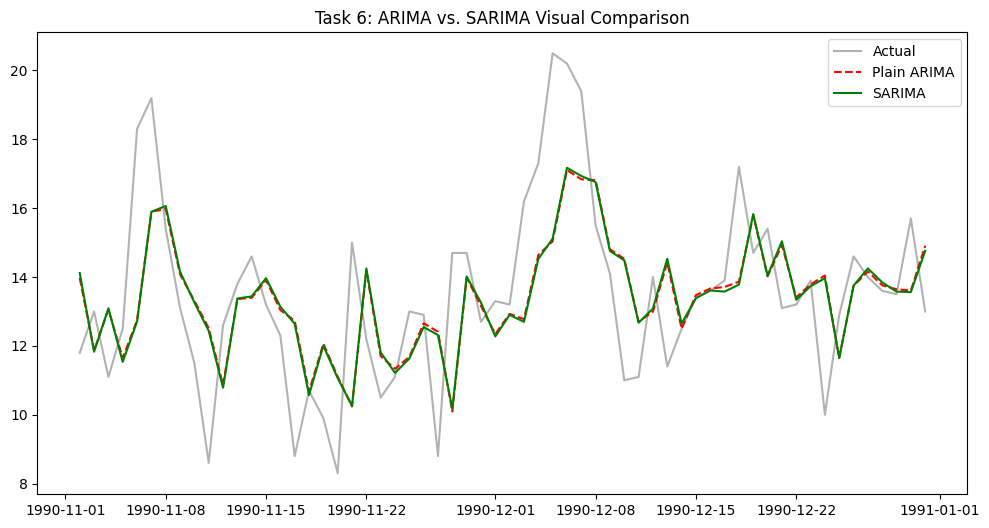

In [97]:
#Task.6 ARIMA vs. SARIMA Visual Comparison
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA with weekly seasonality (s=7) for daily data
model_sarima = SARIMAX(df["Temp"], order=(1, 1, 2), seasonal_order=(1, 1, 1, 7))
results_sarima = model_sarima.fit()

# Visual Comparison
plt.figure(figsize=(12, 6))
plt.plot(df["Temp"].tail(60), label='Actual', color='black', alpha=0.3)
plt.plot(arima_result.predict(start=df.index[-60]), label='Plain ARIMA', color='red', linestyle='--')
plt.plot(results_sarima.predict(start=df.index[-60]), label='SARIMA', color='green')
plt.title("Task 6: ARIMA vs. SARIMA Visual Comparison")
plt.legend()
plt.show()

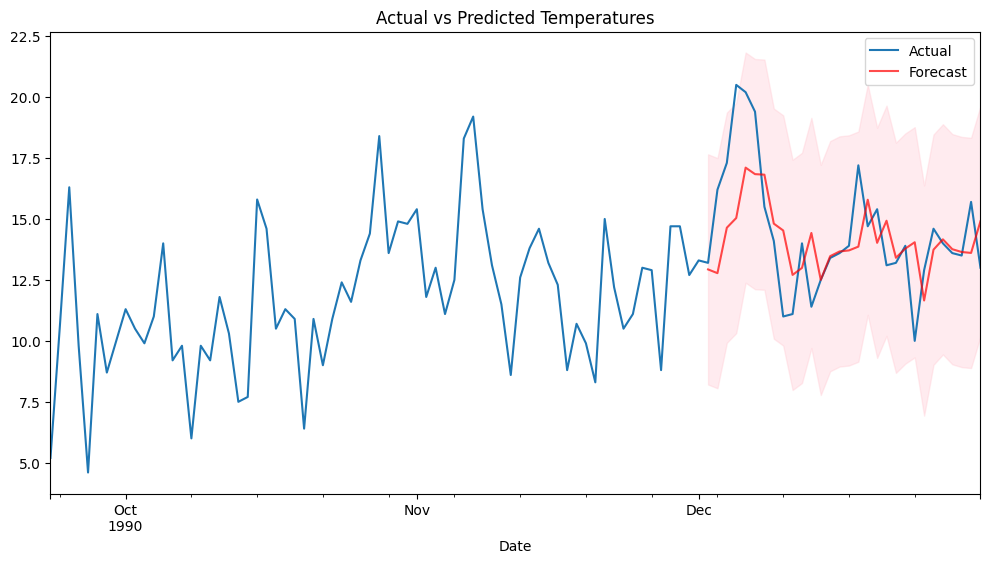

In [90]:
import matplotlib.pyplot as plt


forecast = model_fit.get_prediction(start=-30)
forecast_ci = forecast.conf_int()

ax = df["Temp"][-100:].plot(label='Actual', figsize=(12, 6))
forecast.predicted_mean.plot(ax=ax, label='Forecast', alpha=.7, color='red')

plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='pink', alpha=.3)

plt.title("Actual vs Predicted Temperatures")
plt.legend()
plt.show()

In [23]:
forecast = model_fit.forecast(steps=len(test))
print(forecast.head())

3647    13.095322
3648    13.564120
3649    13.678267
3650    13.706061
3651    13.712828
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [101]:
#Task.7 Train/Test Split & Forecast Accuracy
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Split and Forecast
test_size = 30
actual = df["Temp"].tail(test_size)
forecast = results_arima.get_prediction(start=-test_size).predicted_mean

# Calculate Accuracy
rmse = np.sqrt(mean_squared_error(actual, forecast))
mae = mean_absolute_error(actual, forecast)

print(f"Accuracy -> RMSE: {rmse:.3f}, MAE: {mae:.3f}")

Accuracy -> RMSE: 2.134, MAE: 1.585


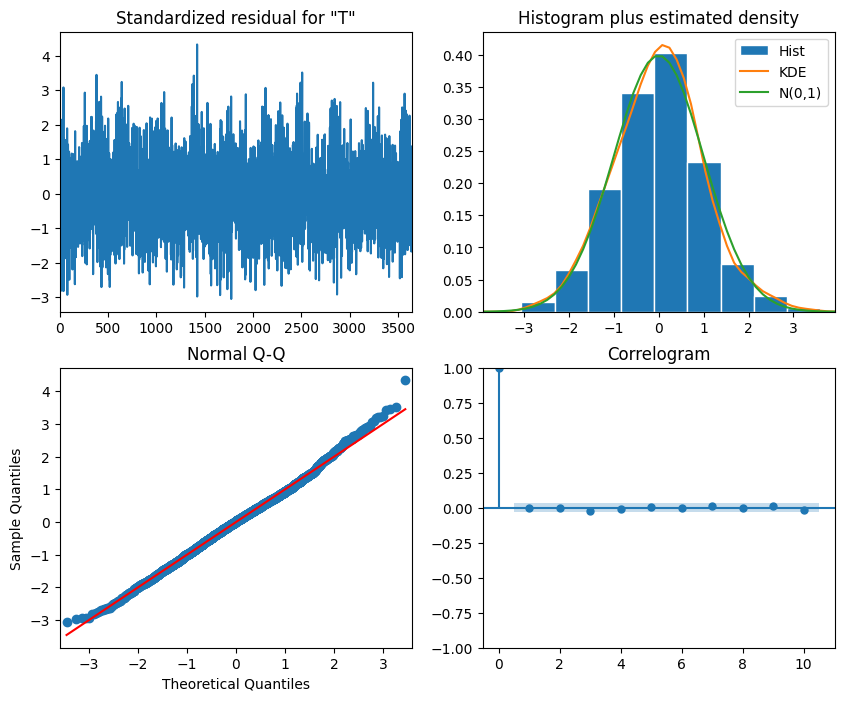

In [100]:
# Task 8: Diagnostics Checklist
results_arima.plot_diagnostics(figsize=(10, 8))
plt.show()
# Note: Check if the histogram is normally distributed and ACF is within bounds.

In [118]:
#Task 9
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. RE-DEFINING ARIMA PREDICTIONS (Week 4 - Task 7)
# Use the model we already trained (results_arima) to get the last 30 days
forecast_res = results_arima.get_prediction(start=-30)
arima_pred = forecast_res.predicted_mean
actual = df["Temp"].tail(30)

# 2. RE-DEFINING MLP PREDICTIONS (Week 5 - Task 9)
# Use the mlp model we trained to get predictions for the test set
# We take the last 30 values to match the ARIMA window
test_actual = y_test.tail(30)
test_nn_pred = mlp.predict(X_test)[-30:]

# 3. CALCULATE METRICS
rmse_arima = np.sqrt(mean_squared_error(actual, arima_pred))
mae_arima = mean_absolute_error(actual, arima_pred)

rmse_mlp = np.sqrt(mean_squared_error(test_actual, test_nn_pred))
mae_mlp = mean_absolute_error(test_actual, test_nn_pred)

# 4. GENERATE THE FINAL TABLE (Task 10 Deliverable)
comparison_data = {
    "Metric": ["RMSE", "MAE"],
    "ARIMA (Classical)": [round(rmse_arima, 4), round(mae_arima, 4)],
    "Neural Network (MLP)": [round(rmse_mlp, 4), round(mae_mlp, 4)]
}

comparison_df = pd.DataFrame(comparison_data)

print("--- Final Model Comparison ---")
print(comparison_df.to_string(index=False))

# Logic for your 1-page analysis
winner = "ARIMA" if rmse_arima < rmse_mlp else "Neural Network"
print(f"\nRecommended Model for Report: {winner}")

--- Final Model Comparison ---
Metric  ARIMA (Classical)  Neural Network (MLP)
  RMSE             2.1341                2.2504
   MAE             1.5854                1.8836

Recommended Model for Report: ARIMA


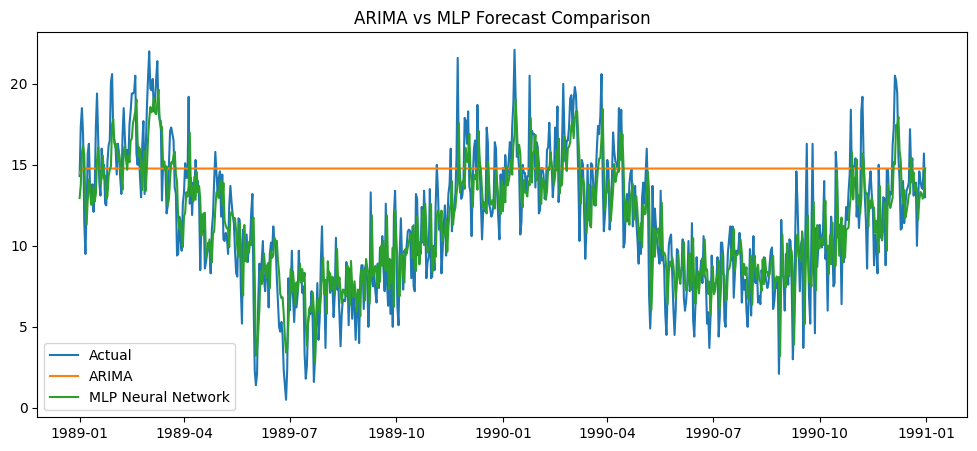

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast_arima, label="ARIMA")
plt.plot(test.index[-len(mlp_pred):], mlp_pred, label="MLP Neural Network")

plt.legend()
plt.title("ARIMA vs MLP Forecast Comparison")
plt.show()